# UniStitch: Matching & Image Stitching (epoch-0 ALIKED model)

- **Model**: `outputs/finetune_aliked_amuse2/checkpoints/best_epoch0001_ssim0.6785.pth`
  (AMUSE averaged iterate after epoch 0 of the UDIS-D ALIKED fine-tune)
- **Baseline**: `model_homo_stage2/epoch_best_model.pth` (released SuperPoint model,
  evaluated with ALIKED descriptors zero-padded to 256-d)
- **Matching**: self-contained RaCo-ALIKED-LightGlue+ v3.0 ONNX pipeline
  (`keypoint_tool/onnx_models.py`)
- **Stitching**: UniStitch stage-2 network + TPS fusion (`Codes/network.py`)

Run with the pixi environment:

```bash
pixi run lab                     # or:
pixi run jupyter nbconvert --to notebook --execute --inplace notebooks/matching_and_stitching_epoch0.ipynb
```

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")  # GPU0 may be busy; use GPU1
os.environ.setdefault("MPLBACKEND", "Agg")


def find_root(start: Path = Path.cwd()) -> Path:
    for path in [start, *start.parents]:
        if (path / "Codes" / "network.py").exists():
            return path
    raise RuntimeError("repository root not found")


ROOT = find_root()
sys.path.insert(0, str(ROOT / "Codes"))
sys.path.insert(0, str(ROOT / "keypoint_tool"))

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

FIG_DIR = ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_EPOCH0 = ROOT / "outputs" / "finetune_aliked_amuse2" / "checkpoints" / "best_epoch0001_ssim0.6785.pth"
CHECKPOINT_BASELINE = ROOT / "model_homo_stage2" / "epoch_best_model.pth"

for checkpoint in (CHECKPOINT_EPOCH0, CHECKPOINT_BASELINE):
    print(f"{checkpoint.name}: exists={checkpoint.exists()}")
print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available())

best_epoch0001_ssim0.6785.pth: exists=True
epoch_best_model.pth: exists=True
torch 2.14.0+cu130 | cuda available: True


## 1. Sample pairs

Two UDIS-D testing pairs and one classical (large-baseline) pair.

In [2]:
SAMPLE_PAIRS = {
    "udis_000002": (
        ROOT / "data/UDIS-D/testing/input1/000002.jpg",
        ROOT / "data/UDIS-D/testing/input2/000002.jpg",
    ),
    "udis_000005": (
        ROOT / "data/UDIS-D/testing/input1/000005.jpg",
        ROOT / "data/UDIS-D/testing/input2/000005.jpg",
    ),
    "classical_000004": (
        ROOT / "data/classical_tmp/stitch_real/input1/000004.jpg",
        ROOT / "data/classical_tmp/stitch_real/input2/000004.jpg",
    ),
}


def read_rgb(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


for name, (path1, path2) in SAMPLE_PAIRS.items():
    image0, image1 = read_rgb(path1), read_rgb(path2)
    print(f"{name}: {image0.shape} / {image1.shape}")

udis_000002: (512, 512, 3) / (512, 512, 3)
udis_000005: (512, 512, 3) / (512, 512, 3)
classical_000004: (662, 1000, 3) / (662, 1000, 3)


## 2. Keypoint matching (RaCo-ALIKED-LightGlue+ v3.0, ONNX)

The self-contained ONNX pipeline detects RaCo keypoints, matches them with
LightGlue+ and samples ALIKED descriptors (`keypoint_tool/onnx_models.py`).

In [3]:
from onnx_models import RaCoAlikedLightGlue

# Force CPU: GPU1 is busy with training and ORT's CUDA arena cannot fit alongside it.
matcher = RaCoAlikedLightGlue(num_threads=8, providers=["CPUExecutionProvider"])

match_results = {}
for name, (path1, path2) in SAMPLE_PAIRS.items():
    image0, image1 = read_rgb(path1), read_rgb(path2)
    result = matcher.match_pair(image0, image1, max_side=1024)
    match_results[name] = result
    print(f"{name}: {len(result['keypoints0'])} matches ({result['descriptors0'].shape[1]}-d descriptors)")

2026-09-14 19:23:40.933832390 [W:onnxruntime:, constant_folding.cc:581 ApplyImpl] Could not find a CPU kernel and hence can't constant fold CastLike node 'node_CastLike_126'
2026-09-14 19:23:40.933908990 [W:onnxruntime:, constant_folding.cc:581 ApplyImpl] Could not find a CPU kernel and hence can't constant fold CastLike node 'node_CastLike_124'
2026-09-14 19:23:40.934995918 [W:onnxruntime:, constant_folding.cc:581 ApplyImpl] Could not find a CPU kernel and hence can't constant fold CastLike node 'node_CastLike_210'
2026-09-14 19:23:40.935031168 [W:onnxruntime:, constant_folding.cc:581 ApplyImpl] Could not find a CPU kernel and hence can't constant fold CastLike node 'node_CastLike_209'
2026-09-14 19:23:40.972156155 [W:onnxruntime:, constant_folding.cc:581 ApplyImpl] Could not find a CPU kernel and hence can't constant fold CastLike node 'node_CastLike_3983'
2026-09-14 19:23:40.972208705 [W:onnxruntime:, constant_folding.cc:581 ApplyImpl] Could not find a CPU kernel and hence can't con

udis_000002: 523 matches (128-d descriptors)


udis_000005: 1261 matches (128-d descriptors)


classical_000004: 443 matches (128-d descriptors)


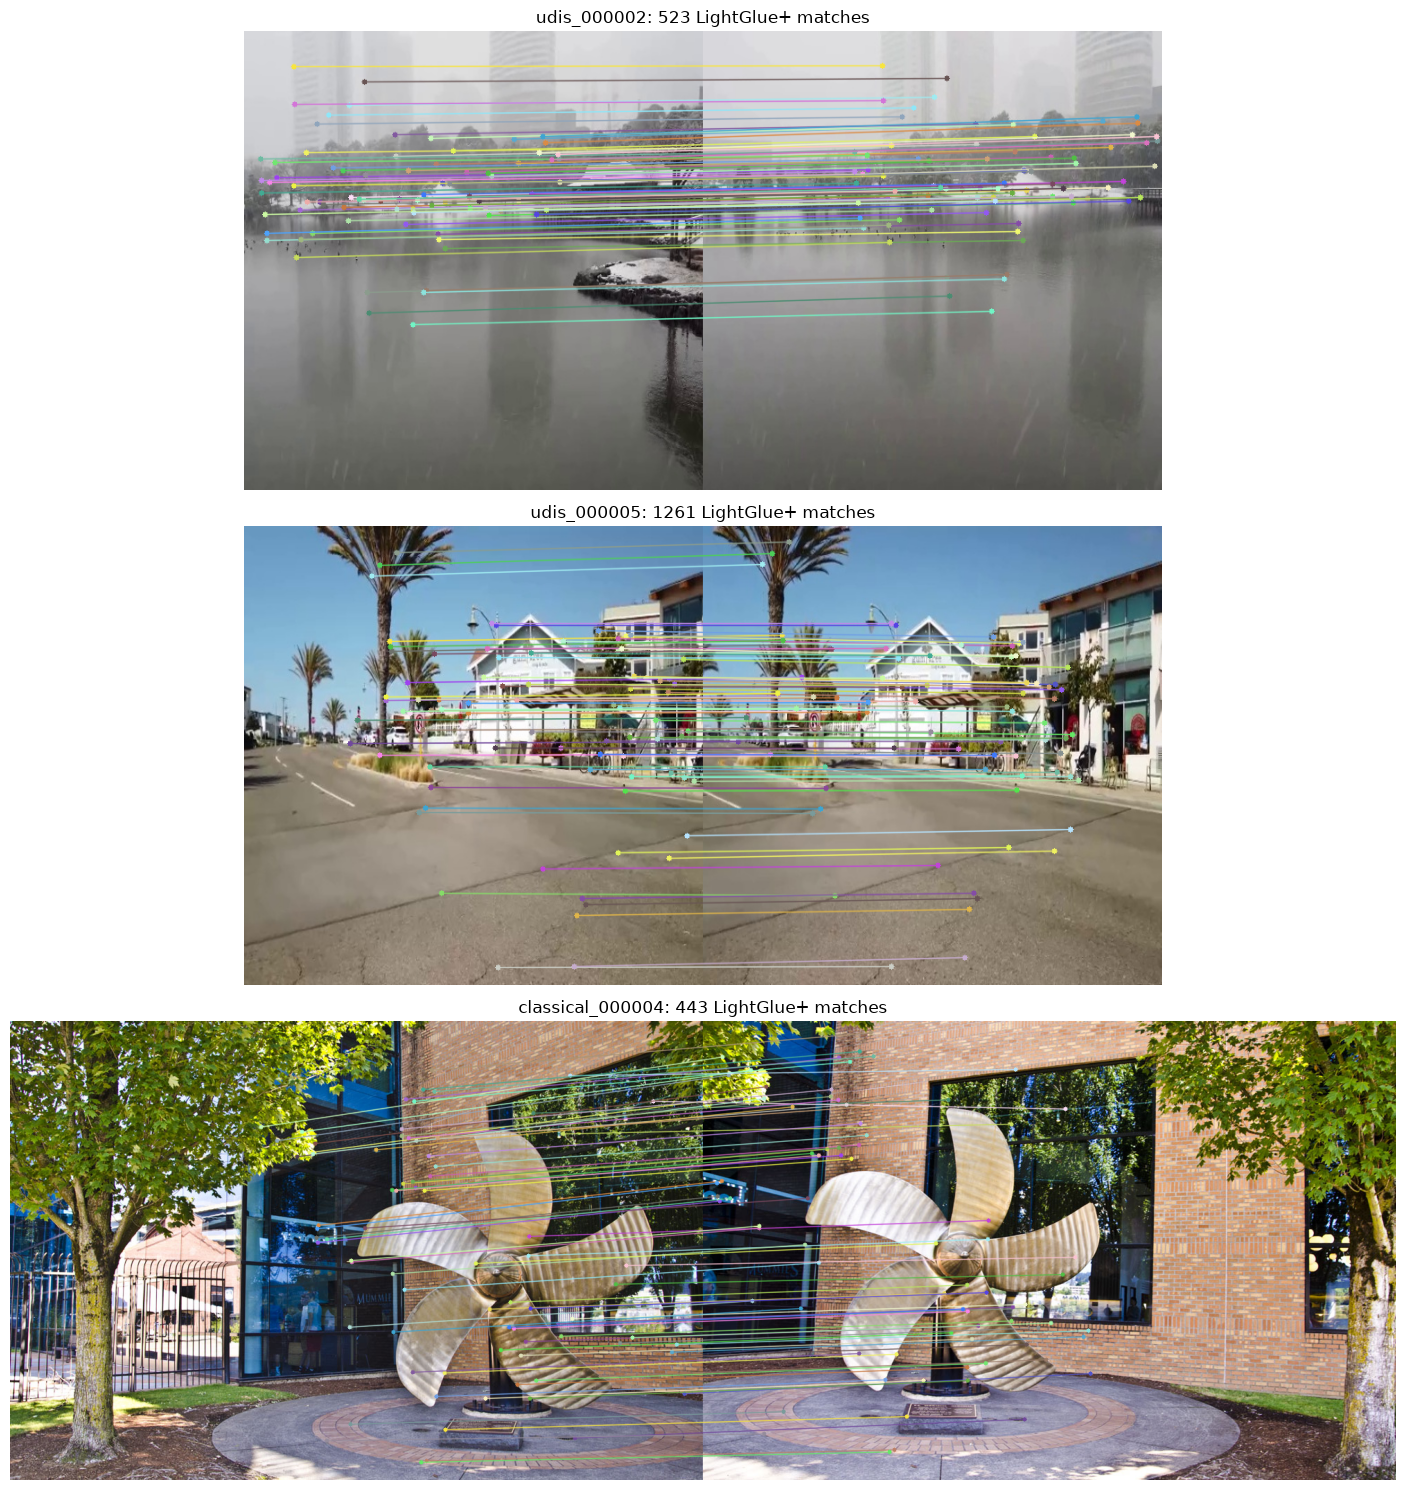

In [4]:
def draw_matches(image0: np.ndarray, image1: np.ndarray, points0: np.ndarray, points1: np.ndarray, max_draw: int = 80):
    canvas = np.concatenate([image0, image1], axis=1)
    width0 = image0.shape[1]
    rng = np.random.default_rng(0)
    indices = rng.choice(len(points0), size=min(max_draw, len(points0)), replace=False)
    for index in indices:
        p0 = tuple(np.round(points0[index]).astype(int))
        p1 = tuple(np.round(points1[index]).astype(int))
        color = tuple(int(value) for value in rng.integers(60, 255, size=3))
        cv2.line(canvas, p0, (p1[0] + width0, p1[1]), color, 1, cv2.LINE_AA)
        cv2.circle(canvas, p0, 3, color, -1)
        cv2.circle(canvas, (p1[0] + width0, p1[1]), 3, color, -1)
    return canvas


figure, axes = plt.subplots(len(SAMPLE_PAIRS), 1, figsize=(16, 5 * len(SAMPLE_PAIRS)))
for axis, (name, (path1, path2)) in zip(np.ravel(axes), SAMPLE_PAIRS.items()):
    result = match_results[name]
    canvas = draw_matches(read_rgb(path1), read_rgb(path2), result["keypoints0"], result["keypoints1"])
    axis.imshow(canvas)
    axis.set_title(f"{name}: {len(result['keypoints0'])} LightGlue+ matches")
    axis.axis("off")
figure.tight_layout()
figure.savefig(FIG_DIR / "matches_epoch0.png", dpi=110)
plt.show()

## 3. Stitching (epoch-0 ALIKED model vs. released baseline)

Keypoints/descriptors come from the `aliked_lmdb` built with the same ONNX
pipeline (`descriptor_pad_dim=256`). The stitched output is the overlap-weighted
fusion of the two bidirectionally warped TPS results.

In [5]:
from dataset import TestDataset
from network import Network, build_output_model
from skimage.metrics import structural_similarity


def load_network(checkpoint_path: Path) -> torch.nn.Module:
    net = Network(descriptor_dim=256)
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    state = checkpoint["model"] if isinstance(checkpoint, dict) and "model" in checkpoint else checkpoint
    model_state = net.state_dict()
    filtered = {
        key: value
        for key, value in state.items()
        if key in model_state and tuple(value.shape) == tuple(model_state[key].shape)
    }
    net.load_state_dict(filtered, strict=False)
    net.eval()
    net.fuse()
    return net.cuda()


def mask_ssim(image1: np.ndarray, image2: np.ndarray, mask: np.ndarray) -> float:
    _, ssim = structural_similarity(image1 * mask, image2 * mask, data_range=255, channel_axis=2, full=True)
    return float(np.sum(ssim * mask) / (np.sum(mask) + 1e-6))


def mask_psnr(image1: np.ndarray, image2: np.ndarray, mask: np.ndarray) -> float:
    image1 = image1 * mask / 255.0
    image2 = image2 * mask / 255.0
    rmse = np.sqrt(np.sum((image1 - image2) ** 2) / mask.sum())
    return float(20 * np.log10(1.0 / rmse))


def stitch_pair(net, dataset: TestDataset, index: int, max_out_height: int = 6000, max_side: int = 1280):
    batch = dataset[index]
    inputs = [value.float().unsqueeze(0).cuda() for value in batch[:6]]
    with torch.no_grad():
        batch_out, flag_check = build_output_model(net, *inputs, max_out_height=max_out_height)
    if not flag_check:
        return None
    output_ref = (batch_out["output_tps_ref"][0, 0:3] * 127.5).clamp(0, 255).cpu().numpy().transpose(1, 2, 0)
    output_tgt = (batch_out["output_tps_tgt"][0, 0:3] * 127.5).clamp(0, 255).cpu().numpy().transpose(1, 2, 0)
    overlap = (batch_out["output_tps_ref"][0, 3:6] * batch_out["output_tps_tgt"][0, 3:6]).cpu().numpy().transpose(1, 2, 0)
    fused = output_ref * (output_ref / (output_ref + output_tgt + 1e-6)) + output_tgt * (
        output_tgt / (output_ref + output_tgt + 1e-6)
    )
    del inputs, batch_out
    torch.cuda.empty_cache()
    fused = np.clip(fused, 0, 255).astype(np.uint8)
    return {
        "fused": fused,
        "ssim": mask_ssim(output_ref, output_tgt, overlap),
        "psnr": mask_psnr(output_ref, output_tgt, overlap),
    }


udis_dataset = TestDataset(
    data_path=str(ROOT / "data/UDIS-D/testing"), keypoint="aliked", descriptor_pad_dim=256, resize_max_side=1280
)
classical_dataset = TestDataset(
    data_path=str(ROOT / "data/classical_tmp/stitch_real"),
    keypoint="aliked",
    descriptor_pad_dim=256,
    resize_max_side=1280,
)


def dataset_index(dataset: TestDataset, filename: str) -> int:
    names = [Path(path).name for path in dataset.datas["input1"]["image"]]
    return names.index(filename)


DATASETS = {
    "udis_000002": (udis_dataset, dataset_index(udis_dataset, "000002.jpg")),
    "udis_000005": (udis_dataset, dataset_index(udis_dataset, "000005.jpg")),
    "classical_000004": (classical_dataset, dataset_index(classical_dataset, "000004.jpg")),
}
print({name: index for name, (_, index) in DATASETS.items()})

Loaded LMDB database from /workspace/UniStitch/data/UDIS-D/testing/aliked_lmdb
Test dataset keys: odict_keys(['input1', 'input2'])
Total test samples: 1105
Loaded LMDB database from /workspace/UniStitch/data/classical_tmp/stitch_real/aliked_lmdb
Test dataset keys: odict_keys(['input1', 'input2'])
Total test samples: 147
{'udis_000002': 0, 'udis_000005': 3, 'classical_000004': 3}


In [6]:
networks = {
    "epoch0": load_network(CHECKPOINT_EPOCH0),
    "baseline": load_network(CHECKPOINT_BASELINE),
}
results = {}
for model_name, net in networks.items():
    for sample_name, (dataset, index) in DATASETS.items():
        outcome = stitch_pair(net, dataset, index)
        if outcome is None:
            print(f"{model_name}/{sample_name}: skipped (warp too large)")
            continue
        results[(model_name, sample_name)] = outcome
        cv2.imwrite(
            str(FIG_DIR / f"fused_{sample_name}_{model_name}.jpg"),
            cv2.cvtColor(outcome["fused"], cv2.COLOR_RGB2BGR),
        )
        print(f"{model_name}/{sample_name}: ssim={outcome['ssim']:.4f} psnr={outcome['psnr']:.4f}")

Fusing layers... 


Fusing layers... 


waring, wrong norm. xyz: torch.Size([1, 2, 2048]) tensor(1.0021, device='cuda:0') tensor(0.0007, device='cuda:0')


/workspace/UniStitch/.pixi/envs/default/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4221.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


epoch0/udis_000002: ssim=0.2217 psnr=9.2246
waring, wrong norm. xyz: torch.Size([1, 2, 2048]) tensor(1.0007, device='cuda:0') tensor(0.0168, device='cuda:0')


epoch0/udis_000005: ssim=0.5260 psnr=12.6711


epoch0/classical_000004: ssim=0.2919 psnr=13.3781
waring, wrong norm. xyz: torch.Size([1, 2, 2048]) tensor(1.0021, device='cuda:0') tensor(0.0007, device='cuda:0')


baseline/udis_000002: ssim=0.2300 psnr=9.1500
waring, wrong norm. xyz: torch.Size([1, 2, 2048]) tensor(1.0007, device='cuda:0') tensor(0.0168, device='cuda:0')


baseline/udis_000005: ssim=0.5464 psnr=13.0143


baseline/classical_000004: ssim=0.2930 psnr=13.3679


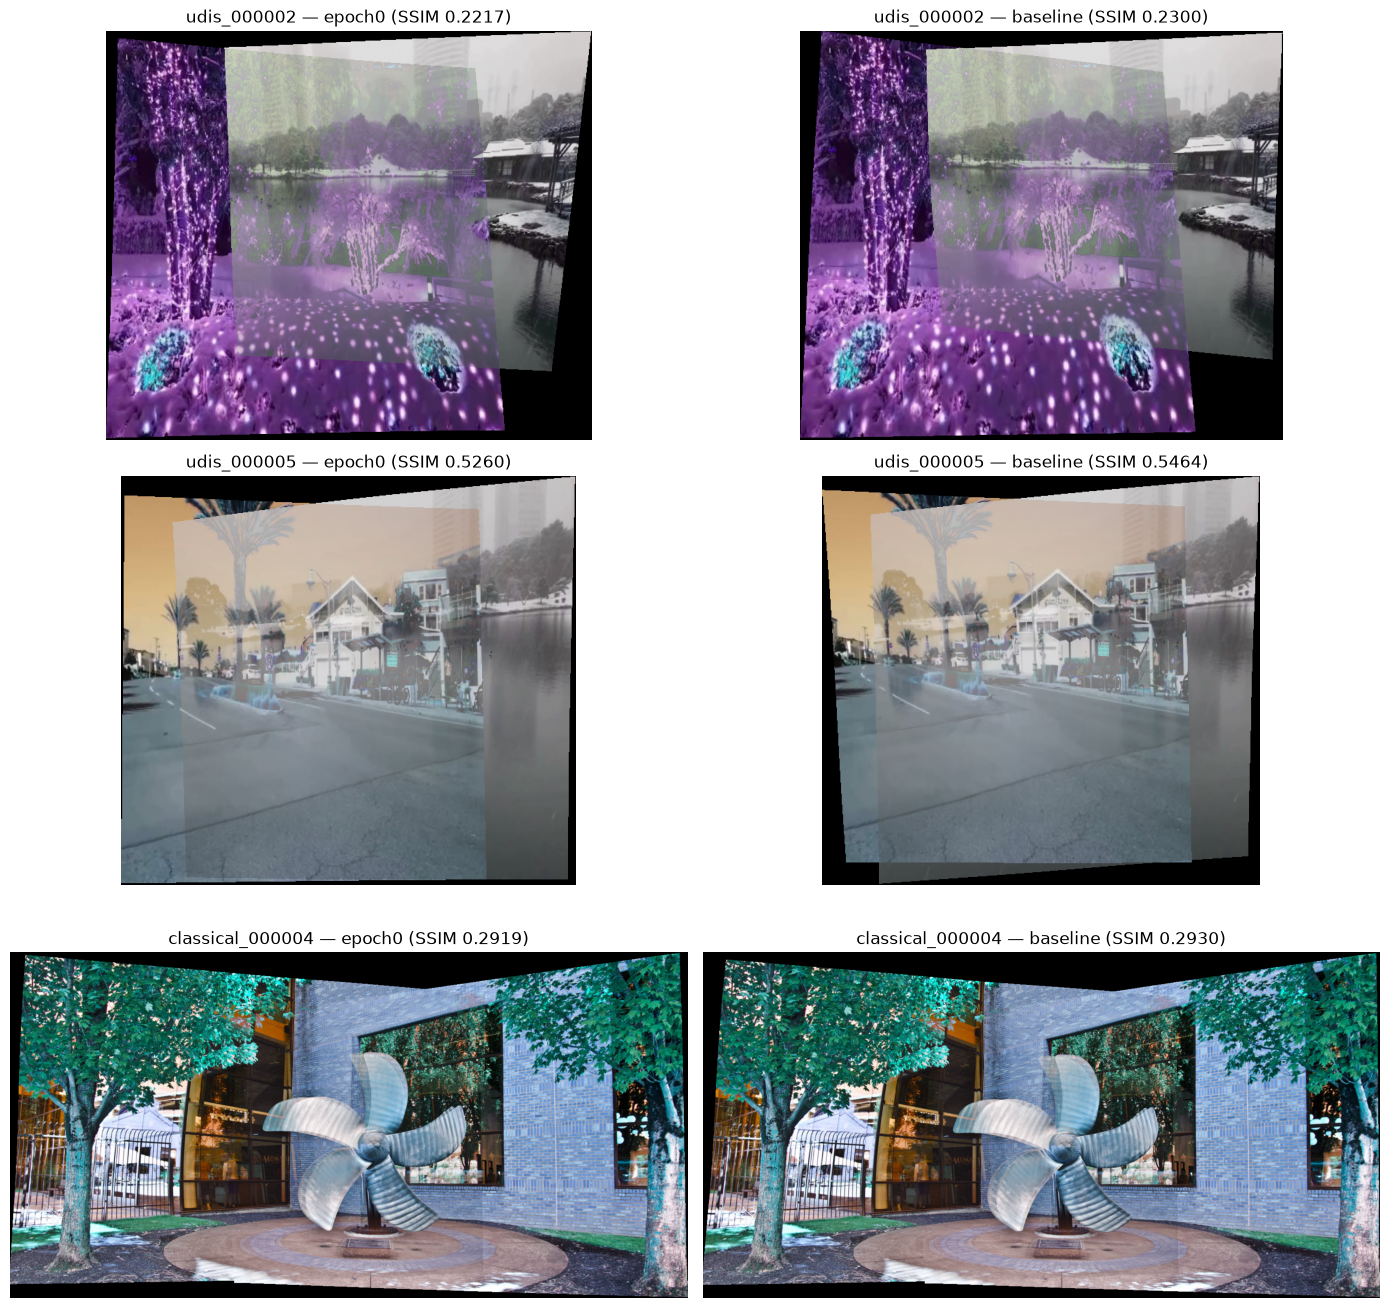

In [7]:
figure, axes = plt.subplots(len(DATASETS), len(networks), figsize=(7 * len(networks), 4.5 * len(DATASETS)))
for column, model_name in enumerate(networks):
    for row, sample_name in enumerate(DATASETS):
        axis = np.ravel(axes)[row * len(networks) + column]
        outcome = results.get((model_name, sample_name))
        if outcome is None:
            axis.axis("off")
            continue
        axis.imshow(outcome["fused"])
        axis.set_title(f"{sample_name} — {model_name} (SSIM {outcome['ssim']:.4f})")
        axis.axis("off")
figure.tight_layout()
figure.savefig(FIG_DIR / "stitching_epoch0_vs_baseline.png", dpi=100)
plt.show()

## 4. Summary

| sample | model | SSIM | PSNR |
|---|---|---|---|

In [8]:
rows = ["| sample | model | SSIM | PSNR |", "|---|---|---|---|"]
for sample_name in DATASETS:
    for model_name in networks:
        outcome = results.get((model_name, sample_name))
        if outcome is None:
            rows.append(f"| {sample_name} | {model_name} | skip | skip |")
        else:
            rows.append(f"| {sample_name} | {model_name} | {outcome['ssim']:.4f} | {outcome['psnr']:.4f} |")
print("\n".join(rows))

| sample | model | SSIM | PSNR |
|---|---|---|---|
| udis_000002 | epoch0 | 0.2217 | 9.2246 |
| udis_000002 | baseline | 0.2300 | 9.1500 |
| udis_000005 | epoch0 | 0.5260 | 12.6711 |
| udis_000005 | baseline | 0.5464 | 13.0143 |
| classical_000004 | epoch0 | 0.2919 | 13.3781 |
| classical_000004 | baseline | 0.2930 | 13.3679 |
